In [1]:
import xarray as xr 
import tams
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
root = "./"
pr_pre = "precipitation_IMERG_1999_WA" # This can be changed to match the data and resolution.
data_path_pr = f"{root}TFM/{pr_pre}_0.25x0.25.nc"

temp_pre = "tb_merg_1999_WA" # This can be changed to match the data and resolution.
data_path_temp = f"{root}TFM/{temp_pre}_0.25x0.25.nc"


In [3]:
pr_data = xr.open_dataset(data_path_pr)
pr_data = pr_data.transpose("time", "lat", "lon") # In order to put dims correctly time,lat,lon.
temp_data = xr.open_dataset(data_path_temp)

In [4]:
pr_data.variables

Frozen({'precipitation': <xarray.Variable (time: 5856, lat: 119, lon: 359)> Size: 1GB
[250174176 values with dtype=float32]
Attributes:
    units:             mm/hr
    DimensionNames:    time,lon,lat
    Units:             mm/hr
    CodeMissingValue:  -9999.9
    LongName:          \nComplete merged microwave-infrared (gauge-adjusted)\..., 'time': <xarray.IndexVariable 'time' (time: 5856)> Size: 47kB
array(['1999-06-01T00:00:00.000000000', '1999-06-01T00:30:00.000000000',
       '1999-06-01T01:00:00.000000000', ..., '1999-09-30T22:30:00.000000000',
       '1999-09-30T23:00:00.000000000', '1999-09-30T23:30:00.000000000'],
      shape=(5856,), dtype='datetime64[ns]')
Attributes:
    standard_name:  time
    axis:           T, 'lon': <xarray.IndexVariable 'lon' (lon: 359)> Size: 3kB
array([-39.75, -39.5 , -39.25, ...,  49.25,  49.5 ,  49.75], shape=(359,))
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X, 'lat'

In [5]:
temp_data.variables

Frozen({'Tb': <xarray.Variable (time: 5856, lat: 119, lon: 359)> Size: 1GB
[250174176 values with dtype=float32]
Attributes:
    standard_name:  brightness_temperature
    units:          K, 'time': <xarray.IndexVariable 'time' (time: 5856)> Size: 47kB
array(['1999-06-01T00:00:00.000000000', '1999-06-01T00:30:00.000000000',
       '1999-06-01T01:00:00.000000000', ..., '1999-09-30T22:30:00.000000000',
       '1999-09-30T23:00:00.000000000', '1999-09-30T23:30:00.000000000'],
      shape=(5856,), dtype='datetime64[ns]')
Attributes:
    standard_name:  time
    axis:           T, 'lon': <xarray.IndexVariable 'lon' (lon: 359)> Size: 3kB
array([-39.75, -39.5 , -39.25, ...,  49.25,  49.5 ,  49.75], shape=(359,))
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X, 'lat': <xarray.IndexVariable 'lat' (lat: 119)> Size: 952B
array([ 0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,  1.75,  2.  ,  2.25,  2.5 ,
        2.75,  3.  ,  

In [6]:
# We need to create a data set that contains both values as tams.run needs tb and precip.

ds_full = xr.merge([temp_data, pr_data])
ds_full = ds_full.rename({"Tb":"ctt","precipitation":"pr"})

In [7]:
ds_full

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 5856, lat: 119, lon: 359)
Coordinates:
  * time     (time) datetime64[ns] 47kB 1999-06-01 ... 1999-09-30T23:30:00
  * lat      (lat) float64 952B 0.25 0.5 0.75 1.0 1.25 ... 29.0 29.25 29.5 29.75
  * lon      (lon) float64 3kB -39.75 -39.5 -39.25 -39.0 ... 49.25 49.5 49.75
Data variables:
    ctt      (time, lat, lon) float32 1GB ...
    pr       (time, lat, lon) float32 1GB ...
Attributes: (12/13)
    CDI:             Climate Data Interface version 2.0.4 (https://mpimet.mpg...
    Conventions:     CF-1.6
    BeginDate:       1999-06-01
    BeginTime:       00:00:00.000Z
    EndDate:         1999-06-01
    EndTime:         00:59:59.999Z
    ...              ...
    InputPointer:    merg_1999060100_4km-pixel
    title:           NCEP/CPC 4km Global (60N - 60S) IR Dataset
    ProductionTime:  2025-08-16T01:55:40.709Z
    DOI:             10.5067/P4HZB9N27EKU
    history:         Wed Feb 18 12:18:29 2026: cdo remapcon2,/home/emohino/wo...
    CDO:             Climate Data Operators version 2.0.4 (https://mpimet.mpg...

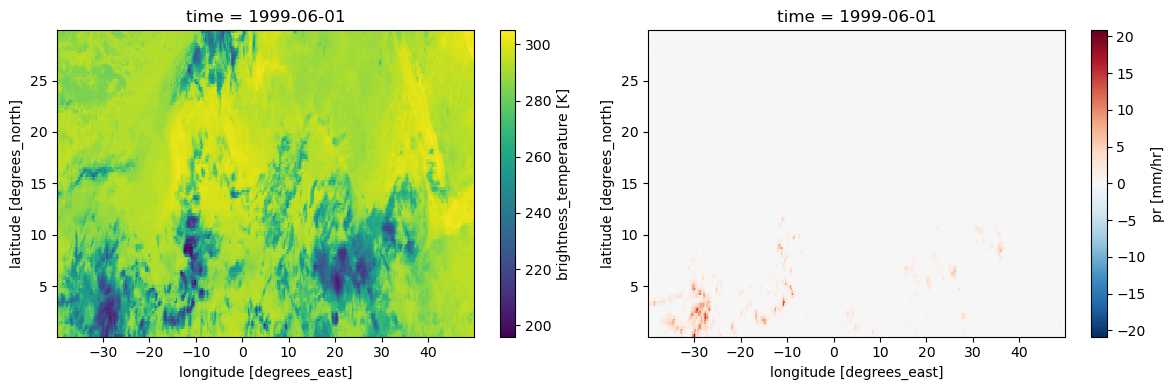

In [8]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))

ds_full.ctt.isel(time=0).plot(ax=ax1)
ds_full.pr.isel(time=0).plot(ax=ax2)

plt.tight_layout()
plt.show()

In [7]:
ds_test = ds_full.sel(time=slice('1999-06-01','1999-06-30'))
ds_test

<xarray.Dataset> Size: 492MB
Dimensions:  (time: 1440, lat: 119, lon: 359)
Coordinates:
  * time     (time) datetime64[ns] 12kB 1999-06-01 ... 1999-06-30T23:30:00
  * lat      (lat) float64 952B 0.25 0.5 0.75 1.0 1.25 ... 29.0 29.25 29.5 29.75
  * lon      (lon) float64 3kB -39.75 -39.5 -39.25 -39.0 ... 49.25 49.5 49.75
Data variables:
    ctt      (time, lat, lon) float32 246MB ...
    pr       (time, lat, lon) float32 246MB ...
Attributes: (12/13)
    CDI:             Climate Data Interface version 2.0.4 (https://mpimet.mpg...
    Conventions:     CF-1.6
    BeginDate:       1999-06-01
    BeginTime:       00:00:00.000Z
    EndDate:         1999-06-01
    EndTime:         00:59:59.999Z
    ...              ...
    InputPointer:    merg_1999060100_4km-pixel
    title:           NCEP/CPC 4km Global (60N - 60S) IR Dataset
    ProductionTime:  2025-08-16T01:55:40.709Z
    DOI:             10.5067/P4HZB9N27EKU
    history:         Wed Feb 18 12:18:29 2026: cdo remapcon2,/home/emohino/wo...
    CDO:             Climate Data Operators version 2.0.4 (https://mpimet.mpg...

In [8]:
ce, mcs, mcs_sumary = tams.run(ds_test, parallel=True)

Starting `identify` 2026-02-27 12:09:16


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=-2)]: Done   4 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-2)]: Done  11 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-2)]: Done  18 tasks      | elapsed:   16.6s
[Parallel(n_jobs=-2)]: Done  27 tasks      | elapsed:   17.1s
[Parallel(n_jobs=-2)]: Done  36 tasks      | elapsed:   17.8s
[Parallel(n_jobs=-2)]: Done  47 tasks      | elapsed:   18.6s
[Parallel(n_jobs=-2)]: Done  58 tasks      | elapsed:   19.5s
[Parallel(n_jobs=-2)]: Done  71 tasks      | elapsed:   20.1s
[Parallel(n_jobs=-2)]: Done  84 tasks      | elapsed:   21.3s
[Parallel(n_jobs=-2)]: Done  99 tasks      | elapsed:   22.7s
[Parallel(n_jobs=-2)]: Done 114 tasks      | elapsed:   23.5s
[Parallel(n_jobs=-2)]: Done 131 tasks      | elapsed:   24.9s
[Parallel(n_jobs=-2)]: Done 148 tasks      | elapsed:   26.0s
[Parallel(n_jobs=-2)]: Done 167 tasks      | elapsed:   27.3s
[Parallel(n_jobs=-2)]: Done 186 tasks      | elapsed:   

Starting `track` 2026-02-27 12:11:12
Starting `classify` 2026-02-27 12:12:31
Starting statistics calculations 2026-02-27 12:14:28
Starting CE aggregation (into MCS time series) 2026-02-27 12:14:28
Starting gridded data aggregation 2026-02-27 12:16:17


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=-2)]: Done   4 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-2)]: Done  11 tasks      | elapsed:   12.3s
[Parallel(n_jobs=-2)]: Done  18 tasks      | elapsed:   14.3s
[Parallel(n_jobs=-2)]: Done  27 tasks      | elapsed:   16.5s
[Parallel(n_jobs=-2)]: Done  36 tasks      | elapsed:   19.3s
[Parallel(n_jobs=-2)]: Done  47 tasks      | elapsed:   22.4s
[Parallel(n_jobs=-2)]: Done  58 tasks      | elapsed:   25.5s
[Parallel(n_jobs=-2)]: Done  71 tasks      | elapsed:   29.1s
[Parallel(n_jobs=-2)]: Done  84 tasks      | elapsed:   33.6s
[Parallel(n_jobs=-2)]: Done  99 tasks      | elapsed:   38.8s
[Parallel(n_jobs=-2)]: Done 114 tasks      | elapsed:   43.7s
[Parallel(n_jobs=-2)]: Done 131 tasks      | elapsed:   48.2s
[Parallel(n_jobs=-2)]: Done 148 tasks      | elapsed:   52.7s
[Parallel(n_jobs=-2)]: Done 167 tasks      | elapsed:   57.5s
[Parallel(n_jobs=-2)]: Done 186 tasks      | elapsed:  1

Computing stats for MCS summary dataset 2026-02-27 12:22:18
Done 2026-02-27 12:22:33


In [9]:
mcs

,time,cs235,cs219,nce,area_km2,area219_km2,mcs_id,mcs_class,mean_pr,std_pr,npixel,mean_pr219,std_pr219,mean_ctt219,std_ctt219,npixel219
0,1999-06-01 00:00:00,"MULTIPOLYGON (((20.75 3.91667, 25.25 4.4, 27.2...","MULTIPOLYGON (((26 5.65, 26.75 6.25, 26.65 6.5...",1,549337.964718,88347.428755,0,DLL,0.438298,0.850639,706,1.50383,1.41338,213.904348,4.358846,115
1,1999-06-01 00:00:00,"MULTIPOLYGON (((-8.75 3.925, -8.5 3.93571, -8....","MULTIPOLYGON (((-8.75 4.08333, -8.5 4.13462, -...",1,9547.960513,4123.252063,1,DSL,3.356578,2.627264,15,5.370626,2.880981,210.333333,4.457204,6
2,1999-06-01 00:00:00,"MULTIPOLYGON (((-10.5 4.83654, -10 4.83696, -9...","MULTIPOLYGON (((-10.5 4.99038, -10 5.01667, -9...",1,16802.891711,7196.500365,2,DSL,1.787618,1.592874,21,2.555441,1.89035,209.888889,7.991315,9
3,1999-06-01 00:00:00,"MULTIPOLYGON (((-9 6.06522, -8.75 6.16667, -8....","MULTIPOLYGON (((-9 6.23913, -8.98214 6.25, -8....",1,136843.146176,65253.293791,3,DLL,0.975289,1.522565,177,1.521858,1.843905,214.494505,13.91432,91
4,1999-06-01 00:00:00,"MULTIPOLYGON (((-11 10.59722, -10.5 10.62097, ...","MULTIPOLYGON (((-11.5 10.75, -11.25 10.75, -10...",1,29911.778868,15626.221054,4,DSL,0.879769,1.062151,42,1.231404,1.264939,217.142857,5.022805,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13531,1999-06-30 23:30:00,"MULTIPOLYGON (((30 2.125, 30.10417 2.25, 30.58...","MULTIPOLYGON (((30 2.42188, 30.05952 2.5, 30.5...",1,56997.058839,38426.900009,1846,DSL,3.652103,5.125771,76,5.5723,5.515769,206.510204,6.59584,49
13532,1999-06-30 23:30:00,"MULTIPOLYGON (((-5 9.78659, -4.75 9.86735, -4....","MULTIPOLYGON (((-5 9.88415, -4.75 9.94898, -4....",2,157368.873231,97698.394116,1850,DSL,3.393976,5.322102,207,5.136919,6.02188,204.717557,8.2362,131
13533,1999-06-30 23:30:00,"MULTIPOLYGON (((-10.5 4.24242, -8.5 4.42683, -...","MULTIPOLYGON (((-10.25 4.42241, -10 4.47143, -...",1,29972.588457,9485.407177,1851,DSL,4.354846,2.875026,40,6.543721,2.755949,214.642857,2.898465,14
13534,1999-06-30 23:30:00,"MULTIPOLYGON (((-13.25 11, -10.5 11.34, -10.25...","MULTIPOLYGON (((-11.5 11.3913, -11 11.43333, -...",1,262166.609869,207695.008828,1852,DSL,1.542596,2.225665,336,1.857414,2.353461,217.284133,26.853176,271


In [ ]:
mcs_sumary

,first_time,last_time,duration,mcs_id,mcs_class,mean_mean_pr,mean_mean_pr219,mean_mean_ctt219,mean_std_ctt219,mean_area_km2,mean_area219_km2,mean_nce,first_centroid,last_centroid,distance_km
0,1999-06-01 00:00:00,1999-06-01 06:30:00,0 days 07:00:00,0,DLL,1.107533,2.105601,213.839856,3.893078,145032.036094,25389.661705,1.285714,POINT (21.5519 6.50945),POINT (22.94387 6.90652),161.134747
1,1999-06-01 00:00:00,1999-06-01 01:30:00,0 days 02:00:00,1,DSL,3.750025,4.797628,211.590007,4.581679,14957.801065,7196.996681,1.0,POINT (-8.78632 4.33213),POINT (-9.04541 4.37893),29.309078
2,1999-06-01 00:00:00,1999-06-01 01:30:00,0 days 02:00:00,2,DSL,2.149528,2.358727,210.235958,5.81985,15515.926823,8456.612839,1.0,POINT (-10.49322 5.4428),POINT (-10.64086 5.19005),32.585399
3,1999-06-01 00:00:00,1999-06-01 05:30:00,0 days 06:00:00,3,DLL,0.739012,1.089279,213.561231,8.994682,102800.587999,55883.309372,1.0,POINT (-10.51373 8.05295),POINT (-11.48195 10.11322),253.411314
4,1999-06-01 00:00:00,1999-06-01 01:00:00,0 days 01:30:00,4,DSL,0.482737,0.639944,215.735653,2.930354,30809.565757,9794.160698,1.0,POINT (-10.89323 11.22285),POINT (-11.22989 11.00462),44.661836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1850,1999-06-30 21:30:00,1999-06-30 23:30:00,0 days 02:30:00,1850,DSL,2.035015,3.289571,206.268884,9.320655,170359.262273,90868.938865,1.2,POINT (-5.31077 11.89854),POINT (-5.85517 11.88797),60.614187
1851,1999-06-30 21:30:00,1999-06-30 23:30:00,0 days 02:30:00,1851,DSL,2.2735,3.177654,215.714286,2.523069,23706.96423,7634.27831,1.0,POINT (-9.52168 5.13106),POINT (-9.73836 4.81831),42.355041
1852,1999-06-30 21:30:00,1999-06-30 23:30:00,0 days 02:30:00,1852,DSL,1.148397,1.430192,221.520873,28.947428,254704.929754,196425.282074,1.0,POINT (-10.53095 13.6399),POINT (-10.94393 13.74127),47.337981
1853,1999-06-30 22:30:00,1999-06-30 23:30:00,0 days 01:30:00,1853,DSL,1.015522,2.940707,211.935988,4.727231,183885.768886,34326.968448,1.0,POINT (34.82981 11.85321),POINT (34.0992 12.9143),143.411776


In [ ]:
# We can check mcs by their duration
long_storms = mcs_sumary[mcs_sumary.duration > pd.Timedelta(hours=6)] # This will catch three types of MCS -> MCC, DLL and CCC.


print(f"Found {len(long_storms)}")

Found 313


In [ ]:
# Let's use a way to reduce the processes times by grouping mcs by duration.

over_6 = mcs_sumary[mcs_sumary['duration']>pd.Timedelta(hours=6)]
targets_id = over_6['mcs_id'].values

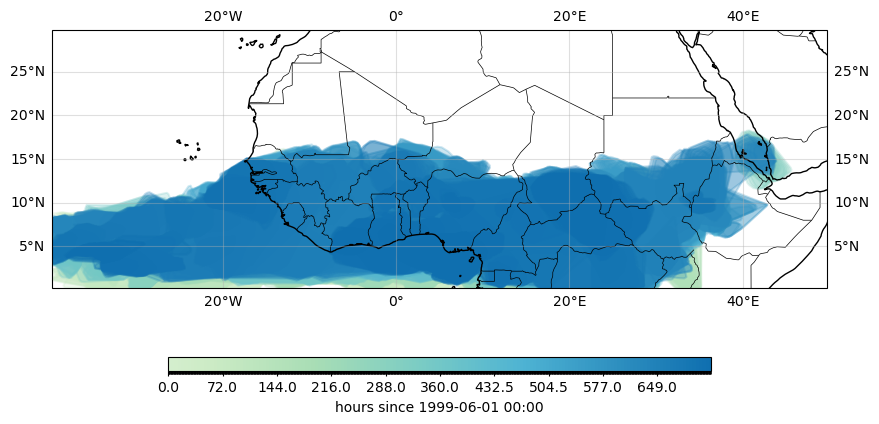

In [ ]:
# Ploting mcs 

lon_min = ds_test.lon.min().values
lon_max = ds_test.lon.max().values
lat_min = ds_test.lat.min().values
lat_max = ds_test.lat.max().values

fig, ax = plt.subplots(figsize=(10,6),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.coastlines(linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, alpha = 0.4, linestyle='-')
#gl = ax.gridlines(
#    draw_labels=True,  # Turns on the degree text
#    color='gray',      # Matches the gray grid lines
#    alpha=0.5,         # Makes the grid lines slightly transparent
#    linestyle='-'
#)


tams.plot_tracked(mcs[mcs['mcs_id'].isin(targets_id)], ax=ax, label="none", add_colorbar=True)
# plot_tracked takes huge time in tracking and plotting mcs and the computational time and processes are proportional to your data preprocesses
# and the temporal/spatial resolution of our ds that we put into the method.

plt.savefig("figure.png", bbox_inches='tight')
plt.show()